In [20]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
import numpy as np
import pandas as pd

np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [22]:
web_logs.head()

,raw
0,"203.0.113.39 - - [01/Mar/2025:00:01:14] ""GET /..."
1,"198.51.100.21 - - [01/Mar/2025:00:02:24] ""GET ..."
2,"198.51.100.17 - - [01/Mar/2025:00:02:28] ""GET ..."
3,"203.0.113.35 - - [01/Mar/2025:00:03:56] ""GET /..."
4,"203.0.113.47 - - [01/Mar/2025:00:14:29] ""GET /..."


In [23]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자
    r" - - \["                            # 고정 구분 부분
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern)
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0


In [30]:
logs["ts_date"] = pd.to_datetime(
    logs["ts"],
    format = "%d/%b/%Y:%H:%M:%S",
    errors = "coerce",
)
logs.head()

,ip,ts,method,path,status,size,ts_date
0,203.0.113.39,01/Mar/2025:00:01:14,GET,/,200,2371,2025-03-01 00:01:14
1,198.51.100.21,01/Mar/2025:00:02:24,GET,/,301,284,2025-03-01 00:02:24
2,198.51.100.17,01/Mar/2025:00:02:28,GET,/search,200,1448,2025-03-01 00:02:28
3,203.0.113.35,01/Mar/2025:00:03:56,GET,/cart,404,3921,2025-03-01 00:03:56
4,203.0.113.47,01/Mar/2025:00:14:29,GET,/products,500,2580,2025-03-01 00:14:29


In [32]:
logs["ts_date"].isna().value_counts()

ts_date
False    1500
Name: count, dtype: int64

In [87]:
logs["status"] = pd.to_numeric(logs["status"], errors="coerce")
logs["status"].unique()

array([200, 301, 404, 500])

In [88]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


In [8]:
logs["method"].value_counts()

method
GET     1157
POST     343
Name: count, dtype: int64

In [9]:
logs[logs.duplicated(subset = ["ip", "ts"], keep = False)]

,ip,ts,method,path,status,size,ts_date


In [24]:
logs.head()

,ip,ts,method,path,status,size
0,203.0.113.39,01/Mar/2025:00:01:14,GET,/,200,2371
1,198.51.100.21,01/Mar/2025:00:02:24,GET,/,301,284
2,198.51.100.17,01/Mar/2025:00:02:28,GET,/search,200,1448
3,203.0.113.35,01/Mar/2025:00:03:56,GET,/cart,404,3921
4,203.0.113.47,01/Mar/2025:00:14:29,GET,/products,500,2580


In [39]:
logs["ts_time"] = logs["ts_date"].dt.hour.sort_index()
logs["ts_time"].value_counts()

ts_time
22    82
1     81
7     81
11    76
19    72
10    70
17    70
13    65
3     63
5     62
12    61
18    61
0     59
8     59
14    59
4     58
21    58
9     57
23    57
2     53
6     51
15    50
16    49
20    46
Name: count, dtype: int64

In [40]:
logs["ts_time"].max()

np.int32(23)

In [56]:
logs["ts_day"] = logs["ts_date"].dt.day_name()
logs["ts_day"].value_counts()

ts_day
Thursday     225
Monday       221
Friday       221
Tuesday      215
Saturday     212
Sunday       208
Wednesday    198
Name: count, dtype: int64

In [57]:
logs.head()

,ip,ts,method,path,status,size,ts_date,ts_time,ts_day
ts_day,,,,,,,,,
Saturday,203.0.113.39,01/Mar/2025:00:01:14,GET,/,200,2371,2025-03-01 00:01:14,0,Saturday
Saturday,198.51.100.21,01/Mar/2025:00:02:24,GET,/,301,284,2025-03-01 00:02:24,0,Saturday
Saturday,198.51.100.17,01/Mar/2025:00:02:28,GET,/search,200,1448,2025-03-01 00:02:28,0,Saturday
Saturday,203.0.113.35,01/Mar/2025:00:03:56,GET,/cart,404,3921,2025-03-01 00:03:56,0,Saturday
Saturday,203.0.113.47,01/Mar/2025:00:14:29,GET,/products,500,2580,2025-03-01 00:14:29,0,Saturday


In [61]:
logs = logs.set_index("ts_date")


In [74]:
hourly_counts = logs["ts_time"].resample("h").size().reset_index(name="count")
hourly_counts["dow_name"] = hourly_counts["ts_date"].dt.day_name()
hourly_counts["hour"] = hourly_counts["ts_date"].dt.hour
pattern = hourly_counts.groupby(["dow_name", "hour"])["count"].sum().reset_index()
print(pattern)

      dow_name  hour  count
0       Friday     0      3
1       Friday     1      8
2       Friday     2      6
3       Friday     3     11
4       Friday     4      9
..         ...   ...    ...
163  Wednesday    19      4
164  Wednesday    20      9
165  Wednesday    21      6
166  Wednesday    22      6
167  Wednesday    23     10

[168 rows x 3 columns]


In [69]:
logs["path"].value_counts()

path
/                184
/search          175
/cart            173
/products/456    171
/products        168
/api/orders      168
/checkout        161
/login           152
/products/123    148
Name: count, dtype: int64

C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pyostry\AppData\Local\Temp\ipykernel_12084\1653101068.py:16: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) 

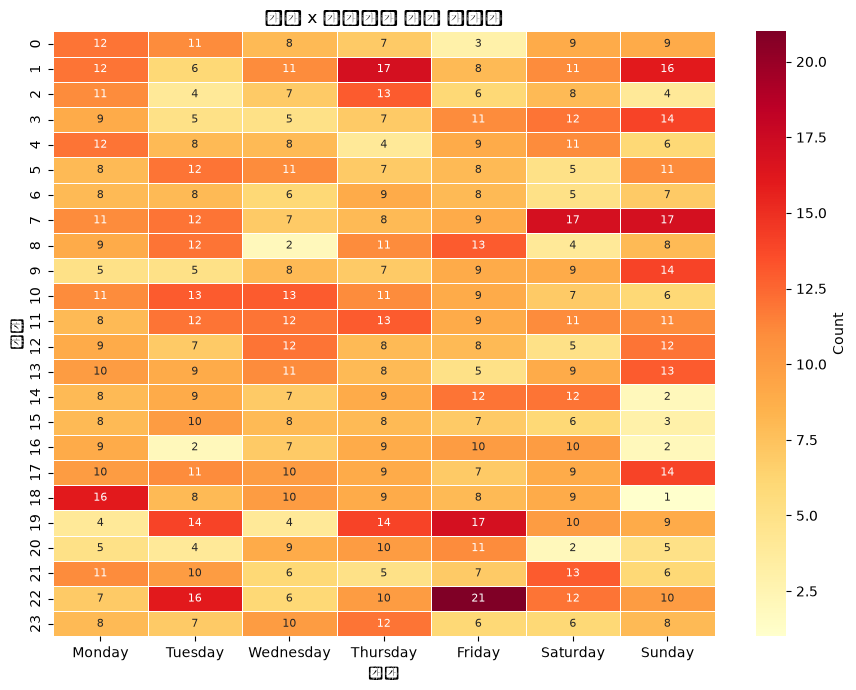

In [81]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot = pattern.pivot(index="hour", columns="dow_name", values="count")[order]

plt.figure(figsize=(9, 7))
sns.heatmap(
    pivot,
    cmap="YlOrRd",              # 낮음(연함) → 높음(진함)
    annot=True, fmt="d",        # 칸마다 실제 숫자도 함께 표시
    annot_kws={"size": 8},
    linewidths=0.5, linecolor="white",   # 칸 사이 구분선
    cbar_kws={"label": "Count"}
)
plt.xlabel("요일")
plt.ylabel("시간")
plt.title("요일 x 시간대별 로그 발생량")
plt.tight_layout()
plt.show()

In [93]:
log_error = logs.loc[logs["status"] >= 400, "path"].value_counts()
print(log_error)

path
/checkout        45
/                44
/cart            43
/products/456    43
/api/orders      40
/products        38
/login           35
/search          32
/products/123    28
Name: count, dtype: int64
